In [1]:
library(dplyr)
library(forcats)
library(Matrix)
library(matrixStats)
library(QR)
library(Seurat)
library(tibble)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count


Loading required package: tinytest

Attaching SeuratObject



In [1]:
library(callr)
r(
  function() {
    library(dplyr)
    library(Seurat)
    library(tibble)
    testis <- CreateSeuratObject(
      readRDS("testis-counts.rds"),
      meta.data = column_to_rownames(readRDS("testis-colData.rds"))
    )
    testis[["RNA"]]@meta.features <- read.csv("dmel-all-r6.31-rowData.csv") %>%
      column_to_rownames()

    set.seed(0)
    Idents(testis) <- testis$ident
    testis <- testis %>%
      SplitObject("batch") %>%
      lapply(
        \(x) x %>%
          NormalizeData(verb = F) %>%
          FindVariableFeatures(nfeatures = 3000, verb = F) %>%
          `VariableFeatures<-`(
            value = union(
              union(
                c("vas", "Acf", "Mst87F"),
                VariableFeatures(.)
              ),
              subset(
                .,
                ident %in% c("spermatogonium", "mid-late proliferating spermatogonia")
              ) %>%
                FindVariableFeatures(nfeatures = 2000, verb = F) %>%
                VariableFeatures()
            )
          )
      ) %>%
      FindIntegrationAnchors(dims = 1:25, anchor.features = 5000) %>%
      IntegrateData(dims = 1:25)
    saveRDS(testis[["integrated"]], "testis-integrated-new.rds")
    dim(testis[["integrated"]])
  },
  show = TRUE
)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Attaching SeuratObject
Computing 5000 integration features
Scaling features for provided objects
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 30057 anchors
Filtering anchors
	Retained 15236 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 30568 anchors
Filtering anchors
	Retained 14693 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 29721 anchors
Filtering anchors
	Retained 14621 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 1792 anchors
Filtering anchors
	Retained 1706 anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 1819 anchors
Filtering anchors
	Retained 1729 anchors
Running CCA
Merging objects
Finding

[1]  5000 43828

In [2]:
data <- readRDS("testis-integrated-new.rds")@data
colData <- left_join(
  tibble(rowname = colnames(data)),
  readRDS("testis-colData.rds"),
  by = "rowname"
)

In [3]:
library(Matrix)

In [4]:
write(deparse(levels(colData$ident)), stdout())

c("spermatogonium", "mid-late proliferating spermatogonia", "spermatogonium-spermatocyte transition", 
"spermatocyte 0", "spermatocyte 1", "spermatocyte 2", "spermatocyte 3", 
"spermatocyte 4", "spermatocyte 5", "spermatocyte 6", "spermatocyte 7a", 
"late primary spermatocyte", "early elongation stage spermatid", 
"early-mid elongation-stage spermatid", "mid-late elongation-stage spermatid", 
"cyst stem cell", "early cyst cell 1", "early cyst cell 2", "spermatocyte cyst cell branch a", 
"spermatocyte cyst cell branch b", "cyst cell branch a", "cyst cell branch b", 
"late cyst cell branch a", "late cyst cell branch b", "adult fat body", 
"muscle cell", "adult tracheal cell", "cyst cell intermediate", 
"head cyst cell", "hemocyte", "male gonad associated epithelium", 
"pigment cell", "secretory cell of the male reproductive tract", 
"spermatid", "spermatocyte", "unknown")


In [5]:
colData$compartment <- colData$ident %>%
  fct_recode(
    germline = "spermatogonium",
    germline = "mid-late proliferating spermatogonia",
    germline = "spermatogonium-spermatocyte transition", 
    germline = "spermatocyte 0", germline = "spermatocyte 1", germline = "spermatocyte 2", germline = "spermatocyte 3", 
    germline = "spermatocyte 4", germline = "spermatocyte 5", germline = "spermatocyte 6", germline = "spermatocyte 7a", 
    germline = "late primary spermatocyte", germline = "early elongation stage spermatid", 
    germline = "early-mid elongation-stage spermatid", germline = "mid-late elongation-stage spermatid", 
    soma = "cyst stem cell", soma = "early cyst cell 1", soma = "early cyst cell 2", soma = "spermatocyte cyst cell branch a", 
    soma = "spermatocyte cyst cell branch b", soma = "cyst cell branch a", soma = "cyst cell branch b", 
    soma = "late cyst cell branch a", soma = "late cyst cell branch b",
    # In PCA-UMAP, adult fat body in the testis samples had neighbors of the spermatid cell types.
    germline = "adult fat body", 
    tissue = "muscle cell", tissue = "adult tracheal cell", soma = "cyst cell intermediate", 
    soma = "head cyst cell", tissue = "hemocyte", tissue = "male gonad associated epithelium", 
    tissue = "pigment cell", tissue = "secretory cell of the male reproductive tract", 
    germline = "spermatid", germline = "spermatocyte",
    tissue = "unknown"
  )
table(colData$compartment)


germline     soma   tissue 
   19643     6358    17827 

In [6]:
scale.data <- data %>% t() %>% scale() %>% t()
scale.data <- matrix(scale.data %>% pmax(-10) %>% pmin(10), nrow = nrow(scale.data), ncol = ncol(scale.data), dimnames = dimnames(scale.data))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.6 GiB”


In [7]:
dim(scale.data)

[1]  5000 43828

In [8]:
S2 <- tcrossprod(scale.data) / (ncol(scale.data) - 1)
# f <- gzfile("testis-s2.csv.gz", "w")
# write.csv(S2, f, row.names=F)

In [9]:
sort(diag(S2))[1001]

CG15865 
0.3239507

In [10]:
sort(diag(S2))[4001]

ed 
 1

In [11]:
genes.spca <- colnames(S2)[rank(diag(S2)) >= 1001]
summary(diag(S2[genes.spca, genes.spca]))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3240  0.9011  0.9999  0.9024  1.0000  1.0000 

In [ ]:
f <- gzfile("testis-s2.csv.gz", "w")
write.csv(S2[genes.spca, genes.spca], f, row.names=F)
close(f)

In [7]:
var(scale.data["nos", ]) * (ncol(scale.data) - 1)
sum(scale.data["nos", ]^2)
var(scale.data["nos", colData$compartment == "germline"]) * (sum(colData$compartment == "germline") - 1)

[1] 43681.35

[1] 43681.35

[1] 40555.82

In [ ]:
centerRows <- \(M) (M - rowMeans2(M))
germline <- scale.data[, colData$compartment == "germline"] %>% centerRows() %>% tcrossprod()
germline <- germline / (ncol(scale.data) - 1)
summary(diag(germline))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.07086 0.24789 0.32563 0.59607 0.92981 

In [40]:
summary(rowVars(scale.data) * (ncol(scale.data) - 1))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  300.5 20960.7 43427.8 32955.0 43827.0 43827.0 

In [41]:
soma <- scale.data[, colData$compartment == "soma"] %>% centerRows() %>% tcrossprod()
soma <- soma / (ncol(scale.data) - 1)
tissue <- scale.data[, colData$compartment == "tissue"] %>% centerRows() %>% tcrossprod()
tissue <- tissue / (ncol(scale.data) - 1)
everything <- (tcrossprod(scale.data) / (ncol(scale.data) - 1)) - germline - soma - tissue

In [42]:
c(germline["AGO3", "AGO3"], soma["AGO3", "AGO3"], tissue["AGO3", "AGO3"], everything["AGO3", "AGO3"])

[1] 0.55698809 0.15254498 0.22278142 0.06768552

In [43]:
summary(diag(everything))

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000133 0.0011237 0.0085217 0.0449638 0.0445267 0.8840997 

In [44]:
sapply(list(germline, soma, tissue, everything), \(M) sum(diag(M) >= 0.25))

[1] 2492  484 2706  227

In [46]:
germline_genes <- colnames(germline)[diag(germline) >= 0.25]
output <- gzfile("testis-spca-input-compartment-germline.csv.gz", "w")
write.csv(
  round(germline[germline_genes, germline_genes], 6),
  output,
  row.names = FALSE
)
close(output)
soma_genes <- colnames(soma)[diag(soma) >= 0.25]
output <- gzfile("testis-spca-input-compartment-soma.csv.gz", "w")
write.csv(
  round(soma[soma_genes, soma_genes], 6),
  output,
  row.names = FALSE
)
close(output)
tissue_genes <- colnames(tissue)[diag(tissue) >= 0.25]
output <- gzfile("testis-spca-input-compartment-tissue.csv.gz", "w")
write.csv(
  round(tissue[tissue_genes, tissue_genes], 6),
  output,
  row.names = FALSE
)
close(output)
everything_genes <- colnames(everything)[diag(everything) >= 0.25]
output <- gzfile("testis-spca-input-squared-between.csv.gz", "w")
write.csv(
  round(everything[everything_genes, everything_genes], 6),
  output,
  row.names = FALSE
)
close(output)

```
env JULIA_DEPOT_PATH=../spcaFeaturesDrosophila/Optimal-SPCA-Depot LD_LIBRARY_PATH=/home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/lib /home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/bin/julia --project=../spcaFeaturesDrosophila --threads=auto ../spcaFeaturesDrosophila/Optimal-SPCA/Algorithm/SPCA.jl testis-spca-input-compartment-germline.csv.gz testis-spca-output-compartment-germline-100000.csv 10 50 100000 0.001 0x2e6e993fe8042b78
env JULIA_DEPOT_PATH=../spcaFeaturesDrosophila/Optimal-SPCA-Depot LD_LIBRARY_PATH=/home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/lib /home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/bin/julia --project=../spcaFeaturesDrosophila --threads=auto ../spcaFeaturesDrosophila/Optimal-SPCA/Algorithm/SPCA.jl testis-spca-input-compartment-soma.csv.gz testis-spca-output-compartment-soma.csv 10 30 500000 0.001 0x2e6e993fe8042b78
env JULIA_DEPOT_PATH=../spcaFeaturesDrosophila/Optimal-SPCA-Depot LD_LIBRARY_PATH=/home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/lib /home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/bin/julia --project=../spcaFeaturesDrosophila --threads=auto ../spcaFeaturesDrosophila/Optimal-SPCA/Algorithm/SPCA.jl testis-spca-input-compartment-tissue.csv.gz testis-spca-output-compartment-tissue-100000.csv 10 30 100000 0.001 0x2e6e993fe8042b78
env JULIA_DEPOT_PATH=../spcaFeaturesDrosophila/Optimal-SPCA-Depot LD_LIBRARY_PATH=/home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/lib /home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/bin/julia --project=../spcaFeaturesDrosophila --threads=auto ../spcaFeaturesDrosophila/Optimal-SPCA/Algorithm/SPCA.jl testis-spca-input-squared-between.csv.gz testis-spca-output-squared-between.csv 10 30 500000 0.001 0x2e6e993fe8042b78
env JULIA_DEPOT_PATH=../spcaFeaturesDrosophila/Optimal-SPCA-Depot LD_LIBRARY_PATH=/home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/lib /home/bookworm/.cache/R/basilisk/1.10.2/spcaFeaturesDrosophila/0.0.2/julia_env/bin/julia --project=../spcaFeaturesDrosophila --threads=auto ../spcaFeaturesDrosophila/Optimal-SPCA/Algorithm/SPCA.jl testis-s2.csv.gz testis-spca-output-100000.csv 10 100 100000 0.001 0x2e6e993fe8042b78
```

In [7]:
v_uncorrected <- bind_rows(
  sapply(
    list(
      germline="testis-spca-output-compartment-germline-100000.csv",
      soma="testis-spca-output-compartment-soma.csv",
      tissue="testis-spca-output-compartment-tissue-100000.csv",
      between="testis-spca-output-squared-between.csv"
    ),
    \(filename) {
      X <- read.csv(filename, check.names=F)
      zeros <- rep(0, nrow=X)
      setNames(
        rep(list(zeros), nrow(scale.data)),
        rownames(scale.data)
      ) %>%
        replace(
          match(colnames(X), rownames(scale.data)),
          as.list(X)
        ) %>%
        as_tibble() %>%
        tibble(
          index = seq_len(nrow(.)),
          expl_var = colSums((crossprod(scale.data, t(as.matrix(.))))^2) / (ncol(scale.data) - 1),
          .
        )
    },
    simplify=FALSE
  ),
  .id = "compartment"
) %>%
  print(n=15)

# A tibble: 140 × 5,003
   compartm…¹ index expl_…²   vas   Acf Mst87F  Antp   Ubx `kl-5`    WDY DIP-z…³
   <chr>      <int>   <dbl> <dbl> <dbl>  <dbl> <dbl> <dbl>  <dbl>  <dbl>   <dbl>
 1 germline       1    6.44 0     0          0     0     0      0  0           0
 2 germline       2    5.00 0     0          0     0     0      0  0           0
 3 germline       3    5.39 0     0          0     0     0      0  0           0
 4 germline       4    5.92 0     0          0     0     0      0 -0.360       0
 5 germline       5    5.53 0     0          0     0     0      0  0           0
 6 germline       6    4.35 0     0          0     0     0      0  0           0
 7 germline       7    4.99 0     0          0     0     0      0  0           0
 8 germline       8    3.79 0     0          0     0     0      0  0           0
 9 germline       9    3.86 0.353 0          0     0     0      0  0           0
10 germline      10    4.75 0     0          0     0     0      0  0           0
11 g

In [8]:
order_uncorrected <- order(-v_uncorrected$expl_var)
cor <- tcrossprod(as.matrix(v_uncorrected[order_uncorrected, -c(1:3)]))
findcor <- abs(cor) - diag(rep(1, nrow(cor)))
R <- 0.01
c(1 + floor((which.max(findcor >= R) - 1) / nrow(cor)), (which.max(findcor >= R) %% nrow(cor)) %>% replace(. == 0, nrow(cor)))

[1] 2 7

In [9]:
print(v_uncorrected[order_uncorrected[c(2, 7)], ])

# A tibble: 2 × 5,003
  compartment index expl_var   vas   Acf Mst87F  Antp   Ubx `kl-5`   WDY DIP-z…¹
  <chr>       <int>    <dbl> <dbl> <dbl>  <dbl> <dbl> <dbl>  <dbl> <dbl>   <dbl>
1 tissue         10     8.00     0     0      0     0     0      0     0       0
2 between         8     6.53     0     0      0     0     0      0     0       0
# … with 4,992 more variables: CG4374 <dbl>, rdo <dbl>, CG8665 <dbl>,
#   CG8012 <dbl>, `kl-3` <dbl>, Rab32 <dbl>, Or83c <dbl>, Snmp2 <dbl>,
#   Fbp1 <dbl>, wat <dbl>, Wnt6 <dbl>, Obp99b <dbl>, Wnt4 <dbl>, CG13067 <dbl>,
#   Ndae1 <dbl>, nub <dbl>, jigr1 <dbl>, `beat-IIIc` <dbl>, Fbp2 <dbl>,
#   robo2 <dbl>, `side-VI` <dbl>, CG15353 <dbl>, salm <dbl>, tnc <dbl>,
#   fru <dbl>, CG45263 <dbl>, Pzl <dbl>, Ppn <dbl>, CG8620 <dbl>,
#   CG34166 <dbl>, Sox102F <dbl>, `cv-2` <dbl>, luna <dbl>, bt <dbl>, …


In [10]:
colnames(v_uncorrected)[-c(1:3)][colSums(v_uncorrected[, -c(1:3)] != 0) >= 2]

[1] "Ubx"              "kl-3"             "wat"             
  [4] "Wnt6"             "jigr1"            "side-VI"         
  [7] "fru"              "Pzl"              "cv-2"            
 [10] "luna"             "asRNA:CR44370"    "lncRNA:CR43314"  
 [13] "sog"              "CG34398"          "kek1"            
 [16] "sona"             "Myo81F"           "Cyp6a16"         
 [19] "Samuel"           "Fas3"             "CG42238"         
 [22] "DIP-theta"        "Ae2"              "Pde9"            
 [25] "Liprin-gamma"     "mfas"             "side-V"          
 [28] "lncRNA:CR31044"   "CG5612"           "CG32719"         
 [31] "Pde8"             "fng"              "bru3"            
 [34] "Slc45-1"          "CG15673"          "snu"             
 [37] "trol"             "wb"               "SKIP"            
 [40] "mirr"             "CG10960"          "lncRNA:CR43626"  
 [43] "dl"               "sky"              "btsz"            
 [46] "pain"             "vn"               "CG4928"          
 [49] "metro"            "CG43207"          "Pgant9"          
 [52] "SPARC"            "eys"              "Sema5c"          
 [55] "5-HT2A"           "CG15096"          "GlcAT-P"         
 [58] "CG42673"          "Rbp9"             "CG40006"         
 [61] "Lim1"             "Best2"            "CG15117"         
 [64] "peb"              "NAAT1"            "pyd"             
 [67] "eya"              "CG9967"           "CG44774"         
 [70] "Btk29A"           "Nha1"             "dpr2"            
 [73] "CG17124"          "CG32532"          "bru1"            
 [76] "bru2"             "shep"             "CG13937"         
 [79] "retn"             "CG30116"          "scyl"            
 [82] "CG10062"          "Glut1"            "Snoo"            
 [85] "CG32369"          "Gmap"             "NFAT"            
 [88] "pre-rRNA:CR45845" "AGO3"             "CG42458"         
 [91] "CG32512"          "fus"              "shot"            
 [94] "CG7255"           "Hsp27"            "Pvr"             
 [97] "Hex-A"            "CG9932"           "Abd-B"           
[100] "Esp"              "rdgA"             "comm3"           
[103] "CG9664"           "caps"             "Cirl"            
[106] "dnc"              "NT5E-2"           "vri"             
[109] "CG12768"          "Cip4"             "Idgf4"           
[112] "CG31145"          "Bx"               "unc-5"           
[115] "lncRNA:CR43264"   "Ccdc85"           "CG12035"         
[118] "plum"             "nuf"              "tim"             
[121] "hdc"              "NimA"             "nmo"             
[124] "cpo"              "dpr21"            "bbg"             
[127] "CG42514"          "Pdp1"             "ed"              
[130] "Buffy"            "CG15890"          "lncRNA:let7C"    
[133] "CG42663"          "mthl10"           "Glut4EF"         
[136] "Sox14"            "msi"              "CG6959"          
[139] "Nost"             "IP3K2"            "Stat92E"         
[142] "CG11155"          "Msp300"           "REPTOR"          
[145] "nAChRalpha1"      "Dbp80"            "msn"             
[148] "CG32521"          "Smr"              "uex"             
[151] "Eip63E"           "lncRNA:roX2"      "cwo"             
[154] "Nuak1"            "mbl"              "jim"             
[157] "lncRNA:roX1"      "CG44102"          "cass"            
[160] "lola"             "Hsp83"            "CG13698"

In [11]:
v0 <- v_uncorrected[order_uncorrected, ]
v_corrected <- v0
k <- sum(unlist(v0[1, -c(1:3)]) != 0)
SPCA <- function(data, v) {
  # X = U D V' sic: Normally the vector u would have the embeddings of the individuals and the
  # vector v would have the feature loadings, but in bioinformatics, the matrix is transposed
  # with the features (genes) in the rows.
  support0 <- head(which(v != 0), k)
  X <- data[names(v), ]
  v0 <- svd(X)$u[, 1]
  v <- v0
  for (iter in 1:10) {
    v <- (X %*% crossprod(X, v))[, 1]
    v[rank(-abs(v)) >= k] <- 0
    v <- v / sum(v^2)
  }
  v <- v * (median(sign(subset(v, v != 0))) %>% replace(. != 1 & . != -1, 1))
  metric1 <- sum(crossprod(X, v)^2)

  X <- X * (seq_len(nrow(X)) %in% support0)
  v2 <- setNames(svd(X)$u[, 1], names(v))
  v2 <- v2 * (median(sign(subset(v2, v2 != 0))) %>% replace(. != 1 & . != -1, 1))
  metric2 <- sum(crossprod(X, v2)^2)

  if (metric2 >= metric1) {
    return(v2)
  } else {
    return(v)
  }
}
deflate.data <- scale.data
for (i in seq_len(nrow(v_corrected))) {
  components <- which(rowAnys(as.matrix(v0[1:i, 3 + which(unlist(v0[i, -c(1:3)]) != 0)]) != 0))
  genes <- names(which(colAnys(as.matrix(v0[components, -c(1:3)]) != 0, useNames = TRUE)))
  v <- SPCA(deflate.data, unlist(v0[i, genes]))
  v <- setNames(rep(0, nrow(deflate.data)), rownames(deflate.data)) %>%
    replace(match(names(v), rownames(deflate.data)), v)
  v_corrected[i, -c(1:3)] <- as.list(v)
  deflate.data <- deflate.data - (v %*% crossprod(v, deflate.data))
  gc()
}
v_corrected <- v_corrected %>%
  mutate(
    expl_var = colSums((crossprod(scale.data, t(as.matrix(.[, -c(1:3)]))))^2) / (ncol(scale.data) - 1)
  )
v_corrected <- arrange(v_corrected, desc(expl_var))
genes

[1] "kl-3"           "side-VI"        "Pde9"           "trol"          
 [5] "CG10960"        "dl"             "sky"            "CG4928"        
 [9] "Pgant9"         "5-HT2A"         "CG15096"        "CG42673"       
[13] "CG10082"        "Best2"          "dsx"            "CG31324"       
[17] "pigs"           "CG33970"        "bru1"           "jbug"          
[21] "scyl"           "Snoo"           "CG32369"        "Fas2"          
[25] "Fur1"           "fus"            "Pvr"            "Hex-A"         
[29] "Abd-B"          "CanA-14F"       "FER"            "CG43759"       
[33] "dnc"            "Cip4"           "Sdc"            "CG15822"       
[37] "px"             "CrebA"          "Bx"             "Pura"          
[41] "mam"            "puc"            "Flo2"           "ed"            
[45] "Buffy"          "Rgl"            "CG42663"        "Gdap2"         
[49] "Tm1"            "Sox14"          "msi"            "kuz"           
[53] "kay"            "Nost"           "IP3K2"          "fz2"           
[57] "pico"           "pan"            "Stat92E"        "CG11155"       
[61] "Src42A"         "lncRNA:CR43459" "Xrp1"           "lncRNA:CR42862"
[65] "cwo"            "Nuak1"

In [7]:
v <-  read.csv("testis-spca-output-100000.csv", check.names=F) %>% as.matrix()
v <- v[, match(rownames(scale.data), colnames(v))]
colnames(v) <- rownames(scale.data)
v[is.na(v)] <- 0
v <- v * (apply(v, 1, \(v) median(subset(sign(v), v != 0))) %>% replace(. == 0, 1))
table(sign(as.numeric(v)))
which(rowAnys(v < 0))


    -1      0      1 
     8 499000    992 

[1] 23 33 50 64 80

In [12]:
print(v_corrected)

# A tibble: 140 × 5,003
   compartment index expl_…¹   vas   Acf Mst87F  Antp   Ubx `kl-5`   WDY DIP-z…²
   <chr>       <int>   <dbl> <dbl> <dbl>  <dbl> <dbl> <dbl>  <dbl> <dbl>   <dbl>
 1 tissue          1    8.71     0     0      0 0         0      0 0           0
 2 tissue         10    8.01     0     0      0 0         0      0 0           0
 3 between         1    7.84     0     0      0 0         0      0 0           0
 4 tissue          2    6.72     0     0      0 0.325     0      0 0           0
 5 between         2    6.60     0     0      0 0         0      0 0           0
 6 tissue          3    6.58     0     0      0 0         0      0 0           0
 7 germline        1    6.44     0     0      0 0         0      0 0           0
 8 tissue          7    6.28     0     0      0 0         0      0 0           0
 9 soma            2    6.27     0     0      0 0         0      0 0           0
10 germline        4    5.96     0     0      0 0         0      0 0.342       0
# … 

In [13]:
print(v_corrected[51:60, ])

# A tibble: 10 × 5,003
   compartment index expl_…¹   vas   Acf Mst87F  Antp   Ubx `kl-5`   WDY DIP-z…²
   <chr>       <int>   <dbl> <dbl> <dbl>  <dbl> <dbl> <dbl>  <dbl> <dbl>   <dbl>
 1 tissue         18    3.95 0         0      0     0     0      0     0       0
 2 tissue         15    3.95 0         0      0     0     0      0     0       0
 3 germline       14    3.92 0         0      0     0     0      0     0       0
 4 soma            8    3.90 0         0      0     0     0      0     0       0
 5 germline        9    3.86 0.325     0      0     0     0      0     0       0
 6 germline        8    3.80 0         0      0     0     0      0     0       0
 7 germline       23    3.78 0         0      0     0     0      0     0       0
 8 germline       13    3.77 0         0      0     0     0      0     0       0
 9 soma            4    3.76 0         0      0     0     0      0     0       0
10 between        20    3.73 0         0      0     0     0      0     0       0
# … w

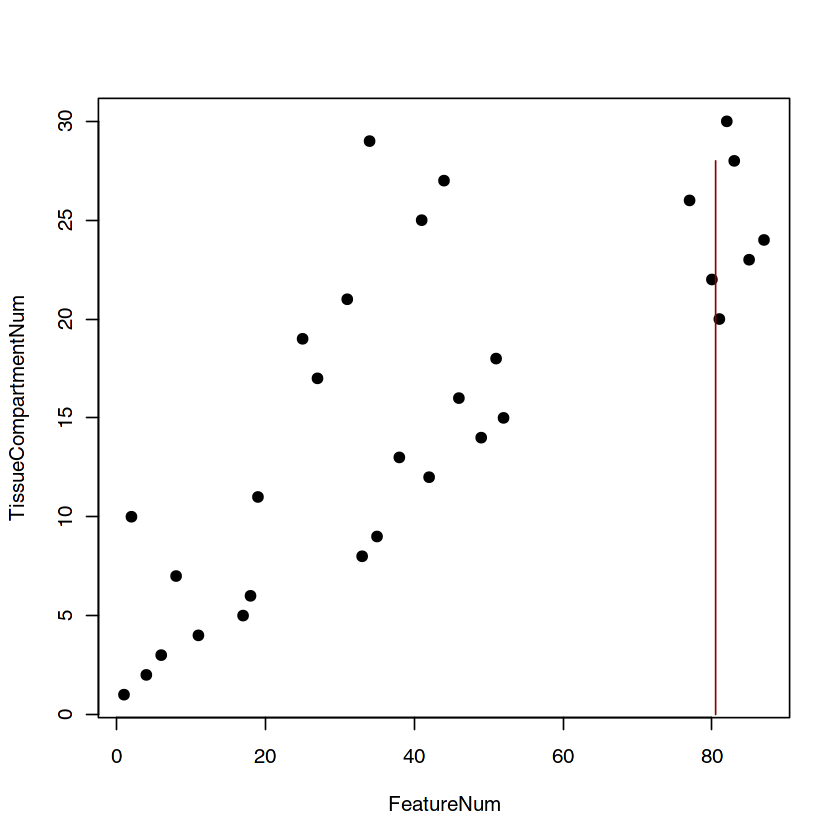

In [14]:
plot(data.frame(FeatureNum=which(v_corrected$compartment == "tissue"), TissueCompartmentNum=subset(v_corrected, compartment == "tissue")$index), pch=19)
lines(rep(80.5, 2), c(0, 28), col='darkred')

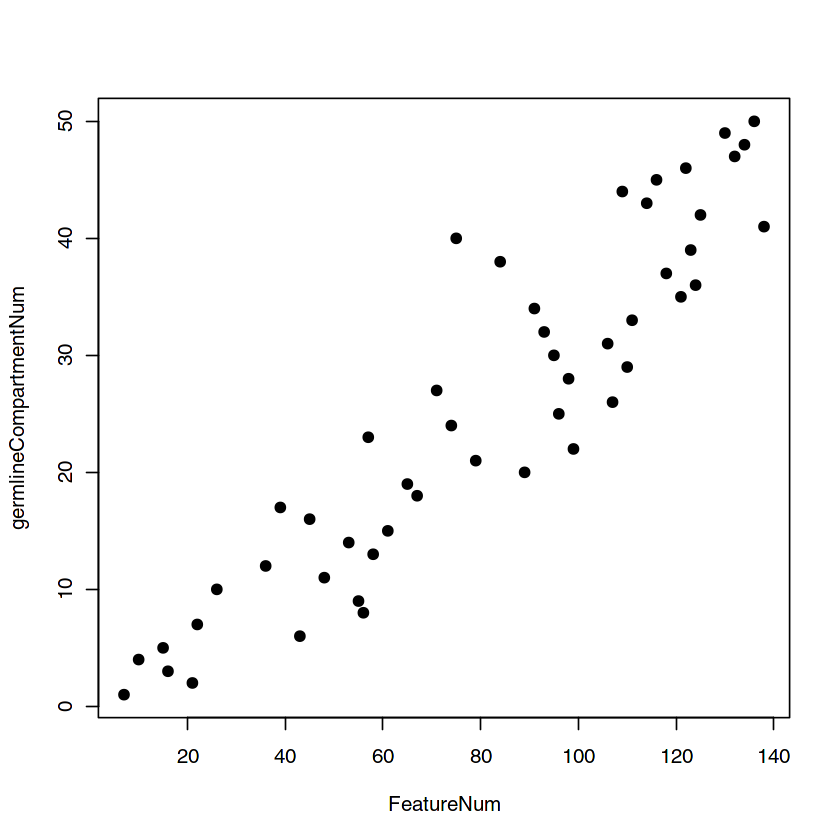

In [15]:
plot(data.frame(FeatureNum=which(v_corrected$compartment == "germline"), germlineCompartmentNum=subset(v_corrected, compartment == "germline")$index), pch=19)

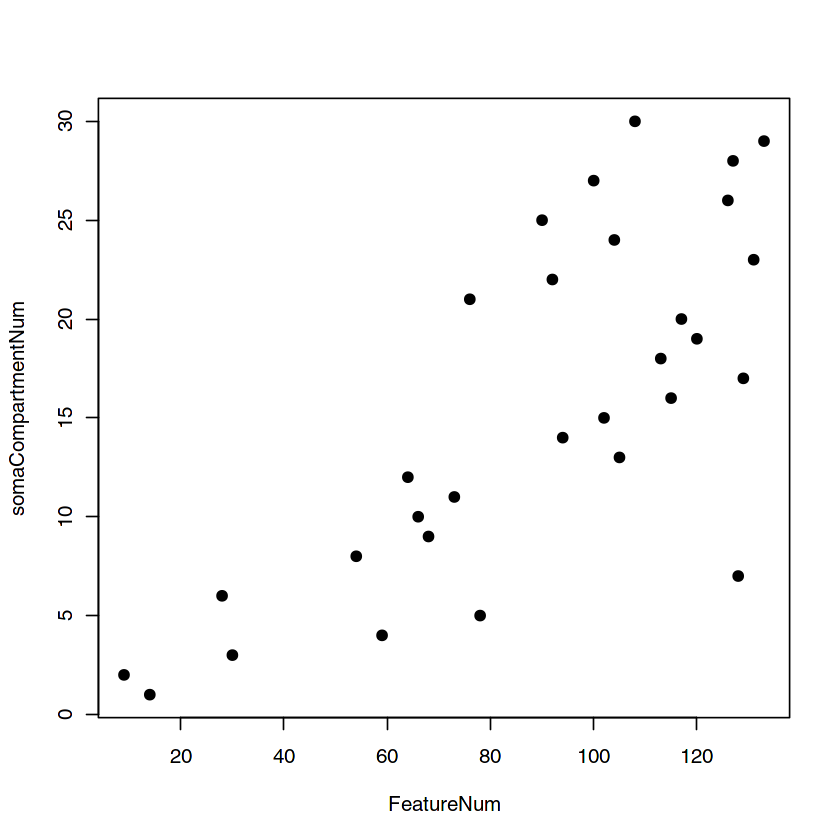

In [16]:
plot(data.frame(FeatureNum=which(v_corrected$compartment == "soma"), somaCompartmentNum=subset(v_corrected, compartment == "soma")$index), pch=19)

In [68]:
round(readRDS("Upd_cpm.rds")[unlist(v[10, ]) %>% subset(. != 0) %>% names(), ], 2)

,germline,somatic,spermatocyte,somaticprecursor,muscle
CG7692,281.59,0.00,94.97,12.03,30.95
lncRNA:CR46148,150.99,0.00,24.49,6.41,0.00
Su(Ste):CR42439,11.23,0.03,0.58,0.00,0.00
ds,2.30,20.39,3.40,9.04,3.14
CG2839,32.61,0.00,13.04,0.00,0.03
lncRNA:CR44560,163.19,0.00,39.48,0.00,0.00
qin,221.59,0.00,53.26,8.43,0.07
Marf1,80.58,0.00,36.93,0.00,14.42
hoip,941.81,277.80,204.10,158.14,156.00
CG12477,170.80,0.00,48.82,13.39,19.45


In [69]:
which.max(v[, "stg"])

[1] 58

In [70]:
round(readRDS("Upd_cpm.rds")[unlist(v[58, ]) %>% subset(. != 0) %>% names(), ], 2)

,germline,somatic,spermatocyte,somaticprecursor,muscle
CG32816,15.43,0.00,4.65,0.00,0.00
stg,282.32,4.63,49.46,40.88,0.00
Ptp61F,178.91,133.33,41.26,28.74,43.90
lncRNA:CR44833,14.25,0.00,4.35,0.00,5.42
Df31,2409.91,2090.47,398.01,1068.35,1073.00
Hasp,125.48,0.00,11.60,11.10,13.19
Drep2,152.31,0.00,31.72,2.12,20.28
c(3)G,196.96,0.70,50.09,0.00,22.11
asRNA:CR45481,20.24,0.00,2.78,0.00,0.00
stet,60.87,0.00,13.76,0.00,0.00


In [8]:
testis <- CreateSeuratObject(CreateAssayObject(data = data), assay = "integrated", meta.data = readRDS("testis-colData.rds") %>% column_to_rownames())

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from integrated to integrated_”


In [9]:
testis[["integrated"]]@scale.data <- scale.data

In [10]:
dim(testis[["integrated"]]@scale.data)

[1]  5000 43828

In [12]:
# all.equal(colnames(v_corrected)[-c(1:3)], rownames(testis[["integrated"]]@scale.data))
testis[["spca"]] <- crossprod(testis[["integrated"]]@scale.data, t(v)) %>%
  `[`(, order(colSds(.), decreasing = TRUE)) %>%
  CreateDimReducObject(
    loadings = as.matrix(t(v)),
    stdev = colSds(.),
    assay = "integrated",
    key = "FEATURE_"
  )
saveRDS(testis[["spca"]], "testis-spca-dimreduc.rds")

Warning message:
“No columnames present in cell embeddings, setting to 'FEATURE_1:100'”


In [13]:
summary(pull(FetchData(testis, "FEATURE_58")))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-2.4080 -1.6237 -0.8096  0.0000  0.9008  9.1056 

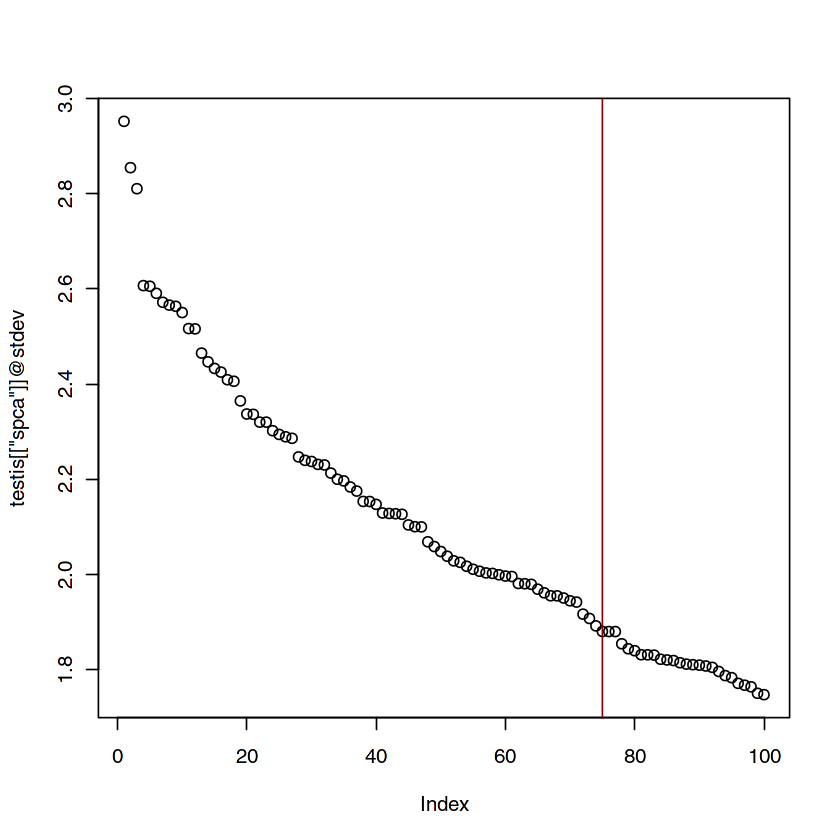

In [18]:
plot(testis[["spca"]]@stdev)
lines(rep(75, 2), c(1, 3), col='darkred')

In [19]:
testis <- testis %>%
  RunUMAP(dims = 1:75, reduction = "spca", seed.use = 0, verbose = FALSE)
testis[["umap"]]@cell.embeddings[, "UMAP_2"] <-
  -testis[["umap"]]@cell.embeddings[, "UMAP_2"]

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


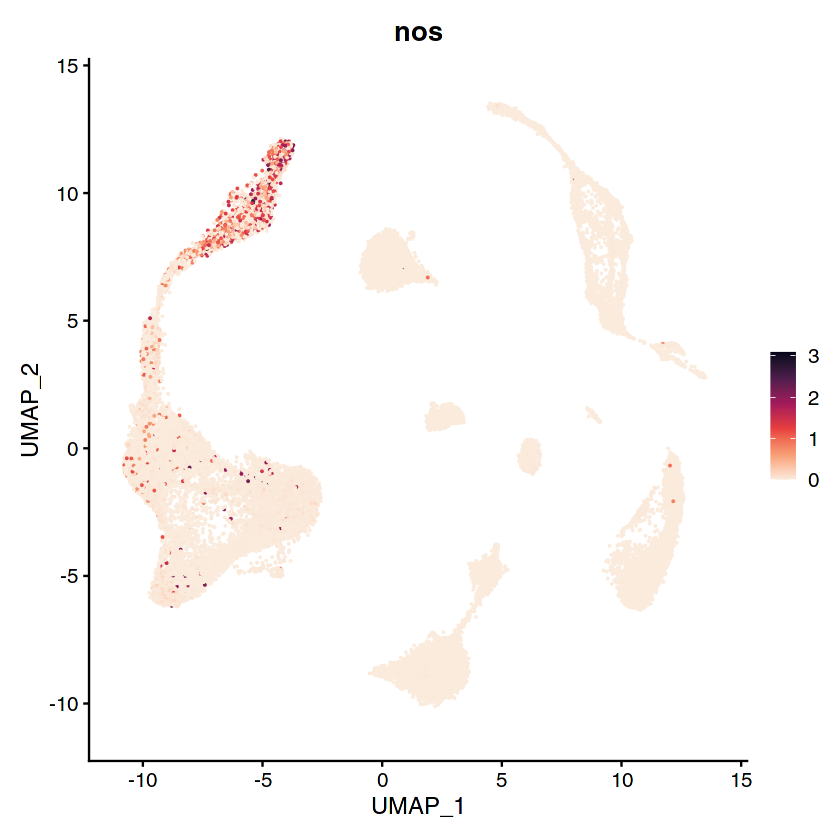

In [20]:
library(ggplot2)
library(scales)
FeaturePlot(testis, "nos") + scale_color_viridis_c(option = "rocket", direction = -1, limits=c(0,NA), oob=squish)

In [21]:
testis <- testis %>% RunPCA(features = rownames(testis[["integrated"]]), npcs = 100, verb = FALSE)

In [22]:
library(stringr)
npcs <- 75
expl_var <- tibble(
    i = 1:100,
    SPC = as.character(str_glue("FEATURE_{i}")),
    PC = as.character(str_glue("PC_{i}")),
) %>%
    rowwise() %>%
    mutate(
        SPC_SG = var(pull(FetchData(testis, SPC, cells = Cells(testis) %>% subset(grepl("spermatogo", testis$ident))))),
        PC_SG = var(pull(FetchData(testis, PC, cells = Cells(testis) %>% subset(grepl("spermatogo", testis$ident))))),
        SPC_CYTE0 = var(pull(FetchData(testis, SPC, cells = Cells(testis) %>% subset(testis$ident == "spermatocyte 0")))),
        PC_CYTE0 = var(pull(FetchData(testis, PC, cells = Cells(testis) %>% subset(testis$ident == "spermatocyte 0")))),
        SPC_CYST = var(pull(FetchData(testis, SPC, cells = Cells(testis) %>% subset(grepl("cyst stem cell|early cyst|branch", testis$ident))))),
        PC_CYST = var(pull(FetchData(testis, PC, cells = Cells(testis) %>% subset(grepl("cyst stem cell|early cyst|branch", testis$ident))))),
    )

In [23]:
expl_var %>% ungroup() %>% summarise(across(matches("SPC."), sum))

SPC_SG,SPC_CYTE0,SPC_CYST
<dbl>,<dbl>,<dbl>
83.47953,44.9758,330.2167


In [24]:
pca_cumsum <- dplyr::slice(ungroup(expl_var), 1:40) %>% ungroup() %>% summarise(i, across(matches("^PC."), cumsum)) %>% print()
(as.matrix(pca_cumsum[1:40, -1] - rep(unlist(ungroup(expl_var) %>% summarise(across(matches("SPC."), sum))), each=40))) %>%
    abs() %>%
    `/`(rep(colMeans(.), each=40)) %>%
    rowSums() %>%
    which.min()

# A tibble: 40 × 4
       i PC_SG PC_CYTE0 PC_CYST
   <int> <dbl>    <dbl>   <dbl>
 1     1  2.57     1.19    10.0
 2     2 16.5      7.94    31.6
 3     3 19.0     10.1     39.8
 4     4 20.6     11.2     55.4
 5     5 23.3     12.4     65.7
 6     6 23.9     12.8     74.8
 7     7 24.2     13.2     83.3
 8     8 24.8     13.4    266. 
 9     9 25.4     13.9    281. 
10    10 30.0     15.4    294. 
# … with 30 more rows


[1] 21

In [25]:
FetchData(testis, c("ident", "UMAP_1", "UMAP_2")) %>%
  subset(grepl("spermato|branch", ident)) %>%
  group_by(ident) %>%
  summarise_all(mean)

ident,UMAP_1,UMAP_2
<fct>,<dbl>,<dbl>
spermatogonium,-4.270229,11.4053938
mid-late proliferating spermatogonia,-4.890027,10.0420413
spermatogonium-spermatocyte transition,-4.954450,9.2816699
spermatocyte 0,-5.623987,8.9563789
spermatocyte 1,-6.683458,8.3241654
spermatocyte 2,-8.149012,7.4460969
spermatocyte 3,-9.071737,6.3770336
spermatocyte 4,-9.590444,4.1191736
spermatocyte 5,-9.644036,2.7492001


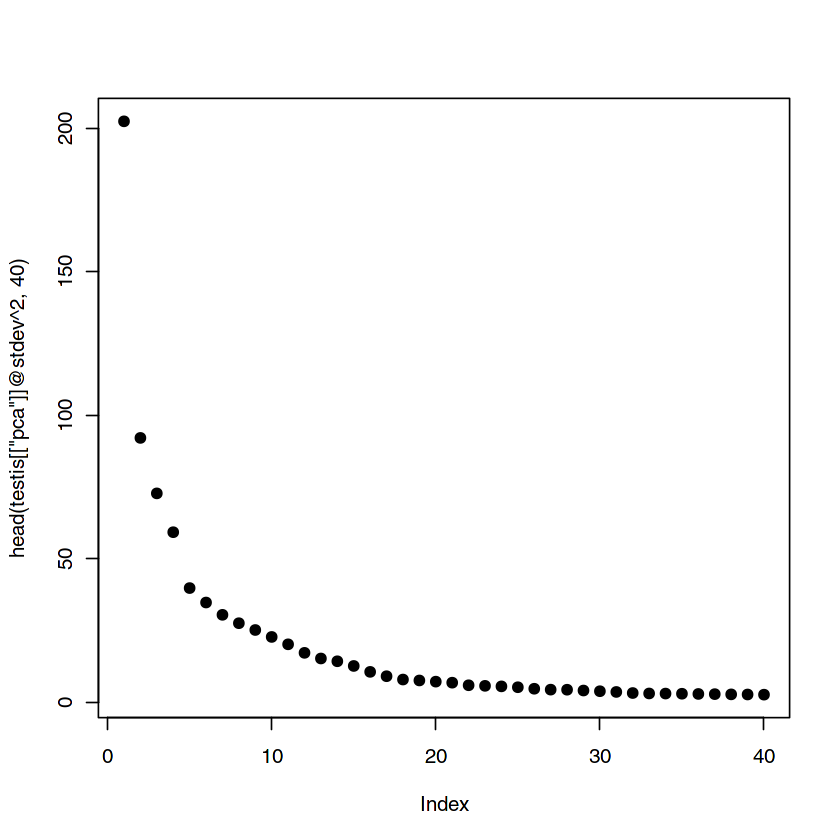

In [26]:
plot(head(testis[["pca"]]@stdev^2, 40), pch=19)

In [27]:
testis <- testis %>%
  RunUMAP(dims = 1:21, reduction.name = "umap.pca", verbose = FALSE)

Warning message:
“Cannot add objects with duplicate keys (offending key: UMAP_), setting key to 'umap.pca_'”


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


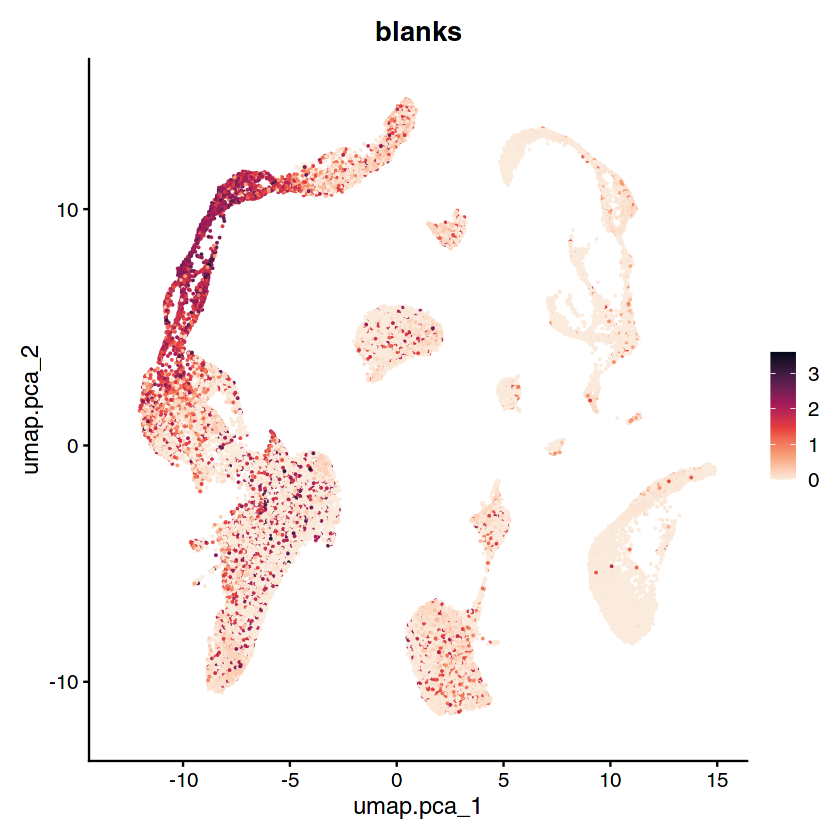

In [28]:
library(ggplot2)
FeaturePlot(testis, "blanks", red="umap.pca") + scale_color_viridis_c(option = "rocket", direction = -1, limits=c(0,NA), oob=squish)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


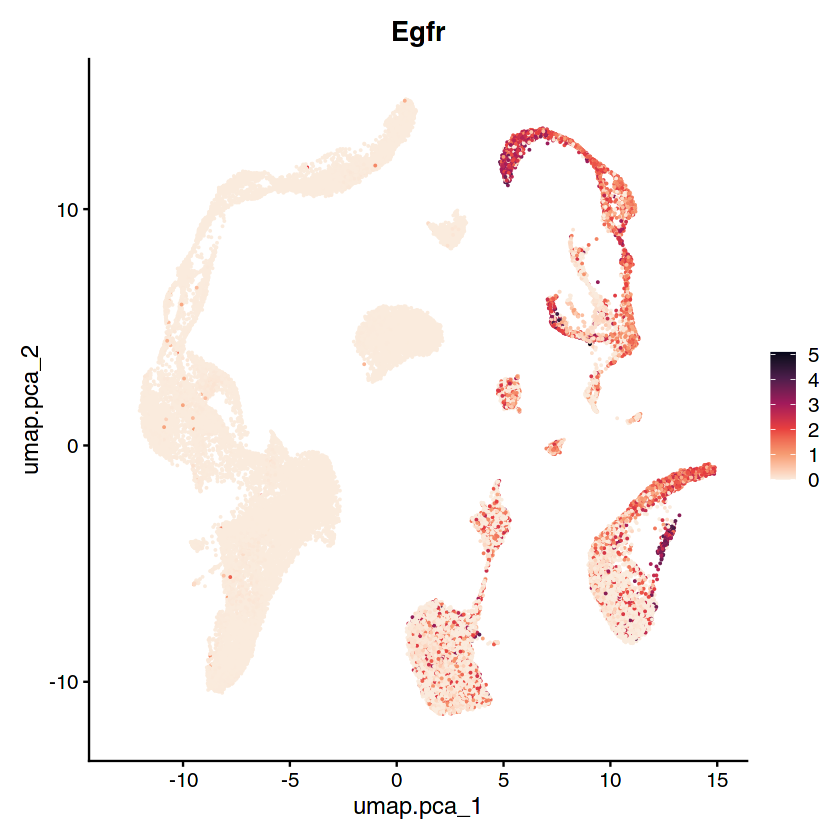

In [29]:
library(ggplot2)
FeaturePlot(testis, "Egfr", red="umap.pca") + scale_color_viridis_c(option = "rocket", direction = -1, limits=c(0,NA), oob=squish)

In [31]:
library(stringr)
FetchData(testis, str_glue("FEATURE_{1:90}"), cells=Cells(testis) %>% subset(testis$ident == "spermatocyte 0")) %>% summarise_all(max) %>% unlist() %>% sort(dec=T) %>% head(10)

FEATURE_30 FEATURE_67 FEATURE_10 FEATURE_80 FEATURE_59 FEATURE_38 FEATURE_66 
 14.769683  13.329662  12.169428   9.888039   9.488987   8.662681   7.688691 
FEATURE_64 FEATURE_78 FEATURE_89 
  7.372719   7.033912   6.136038

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


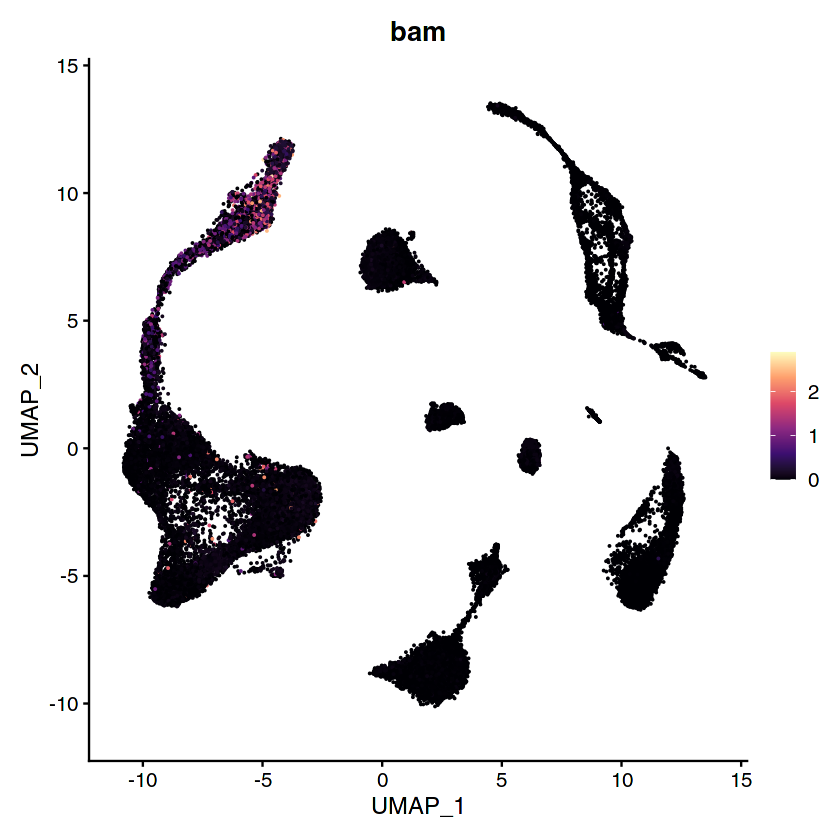

In [32]:
library(ggplot2)
library(scales)
FeaturePlot(testis, "bam") + scale_color_viridis_c(option = "magma", limits=c(0,NA),oob=squish)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


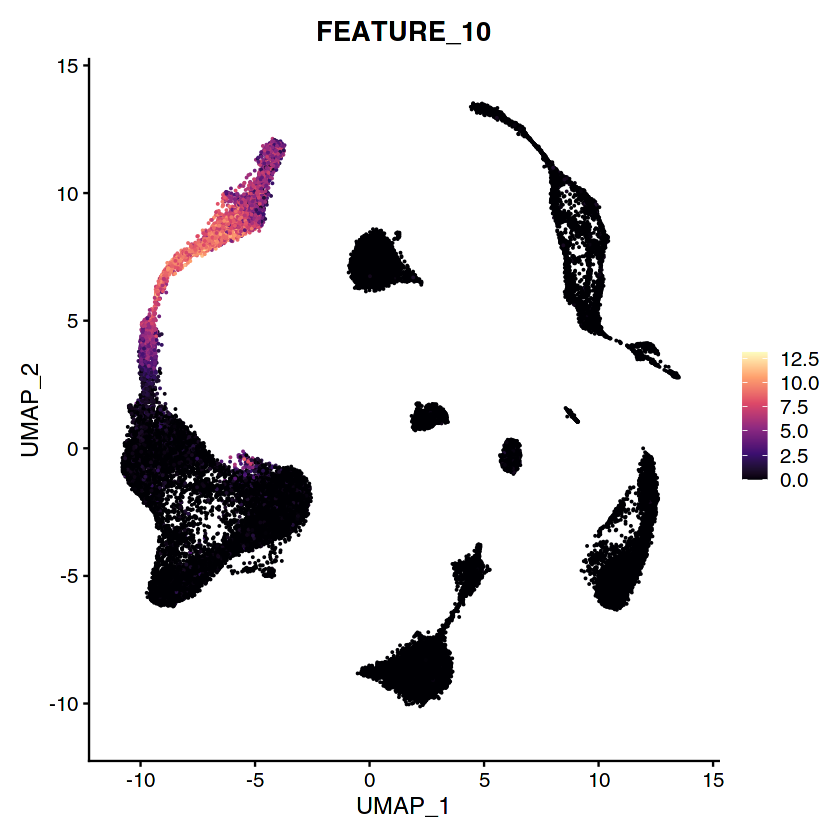

In [ ]:
library(ggplot2)
library(scales)
FeaturePlot(testis, "FEATURE_10") + scale_color_viridis_c(option = "magma", limits=c(0,NA),oob=squish)

In [35]:
testis[["spca"]]@feature.loadings %>% subset(grepl("Su\\(Ste\\)", rownames(.))) %>% subset(select = which(colAnys(. != 0)))

,FEATURE_10,FEATURE_67
Su(Ste):CR42439,0.2948773,0.0000000
Su(Ste):CR42418,0.0000000,0.3043113


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


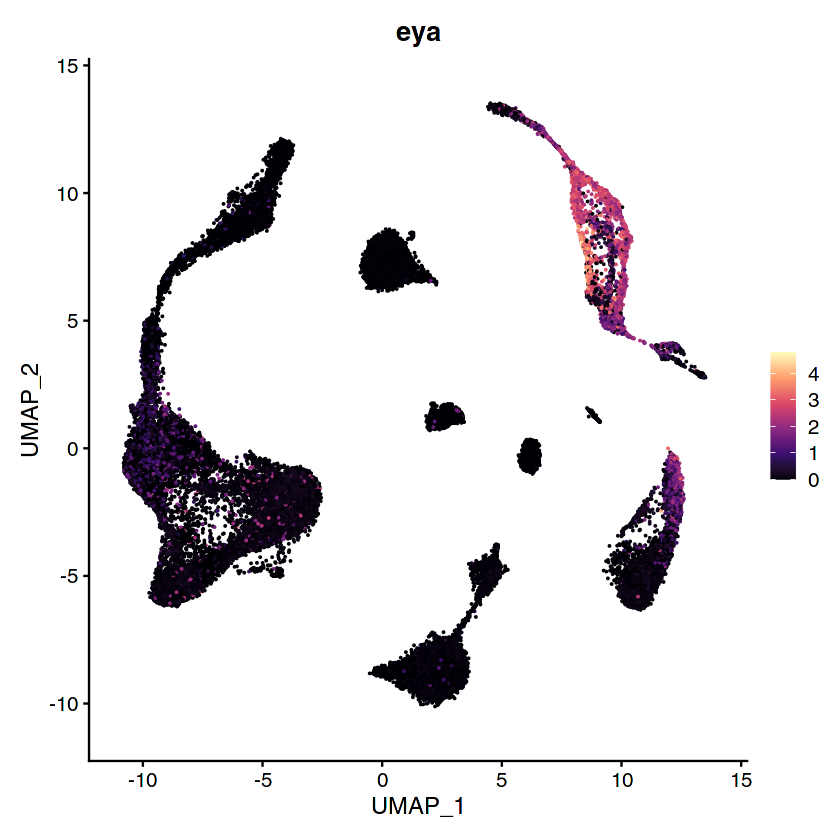

In [36]:
library(ggplot2)
library(scales)
FeaturePlot(testis, "eya") + scale_color_viridis_c(option = "magma", limits=c(0,NA),oob=squish)

In [37]:
testis <- readRDS("testis-spca.rds")
testis[["RNA"]] <- CreateAssayObject(readRDS("testis-counts.rds"))
DefaultAssay(testis) <- "RNA"
testis[["RNA"]]@meta.features <- column_to_rownames(read.csv("dmel-all-r6.31-rowData.csv"))
testis <- testis %>% NormalizeData

In [3]:
cellcycle <- read.csv("Drosophila_melanogaster.csv", quote="")
cellcycle$symbol <- rownames(testis[["RNA"]])[match(cellcycle$geneID, testis[["RNA"]]@meta.features$flybase)]
cellcycle <- cellcycle %>% subset(!is.na(symbol))
v <- (cellcycle$phase == "S") / sum(cellcycle$phase == "S")
testis$S_Score <- FetchData(testis, cellcycle$symbol) %>%
  as.matrix() %>%
  t() %>%
  `/`(rowSds(.)) %>%
  t() %>%
  `/`(rowSums(.)) %>%
  `%*%`(v) %>%
  as.numeric()
testis <- testis %>% CellCycleScoring(s.features = cellcycle$symbol[cellcycle$phase == "S"], cellcycle$symbol[cellcycle$phase == "G2/M"])

In [6]:
write(deparse(viridisLite::turbo(101)[c(9, 50, 91)]), stdout())

c("#424CB7FF", "#9CFE40FF", "#C42503FF")


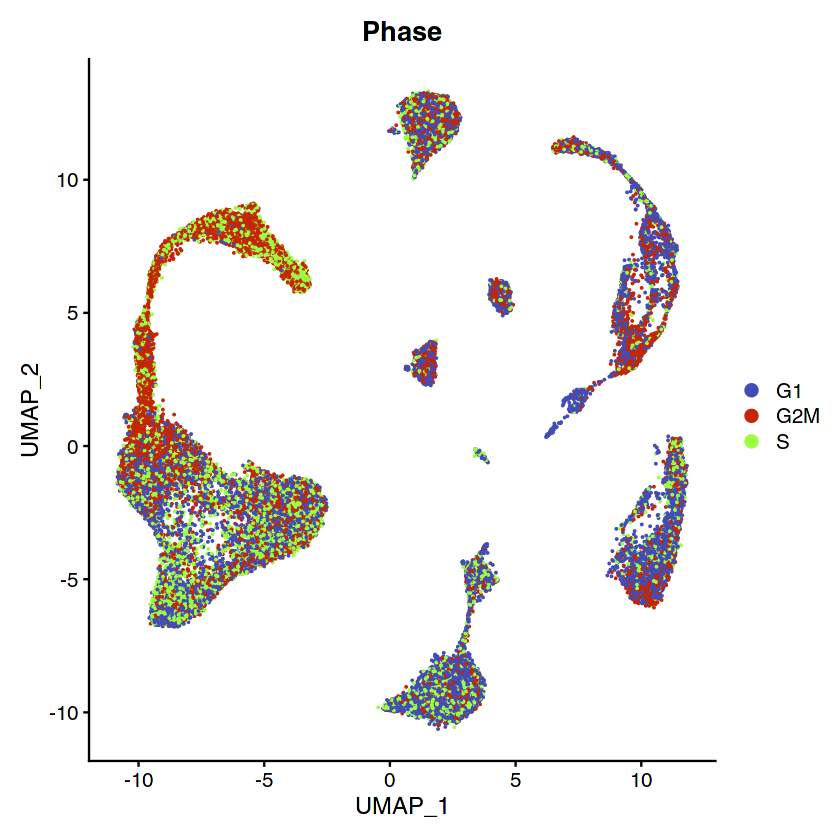

In [8]:
library(ggplot2)
library(scales)
# FeaturePlot(testis, "G2M_Score") + scale_color_viridis_c(option = "magma", limits=c(0,NA),oob=squish,trans="sqrt")
DimPlot(testis, gr='Phase') +
  scale_color_manual(values = c("#424CB7FF", "#C42503FF", "#9CFE40FF"))

In [12]:
print(enframe(table(testis$ident)), n=100)

# A tibble: 36 × 2
   name                                          value      
   <chr>                                         <table[1d]>
 1 spermatogonium                                  717      
 2 mid-late proliferating spermatogonia            406      
 3 spermatogonium-spermatocyte transition          204      
 4 spermatocyte 0                                  999      
 5 spermatocyte 1                                  586      
 6 spermatocyte 2                                  544      
 7 spermatocyte 3                                  344      
 8 spermatocyte 4                                  147      
 9 spermatocyte 5                                  187      
10 spermatocyte 6                                  205      
11 spermatocyte 7a                                 595      
12 late primary spermatocyte                       303      
13 early elongation stage spermatid               6755      
14 early-mid elongation-stage spermatid            949      
15 mi

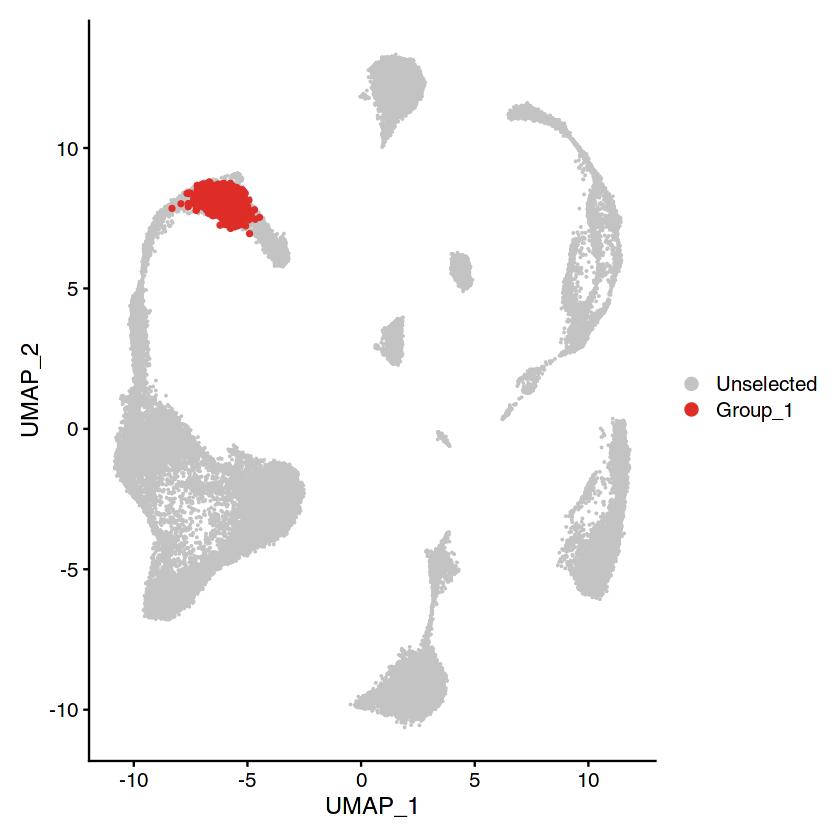

In [18]:
library(ggplot2)
library(scales)
DimPlot(testis, cells.highlight = Cells(testis) %>% subset(testis$ident == "spermatocyte 0"))

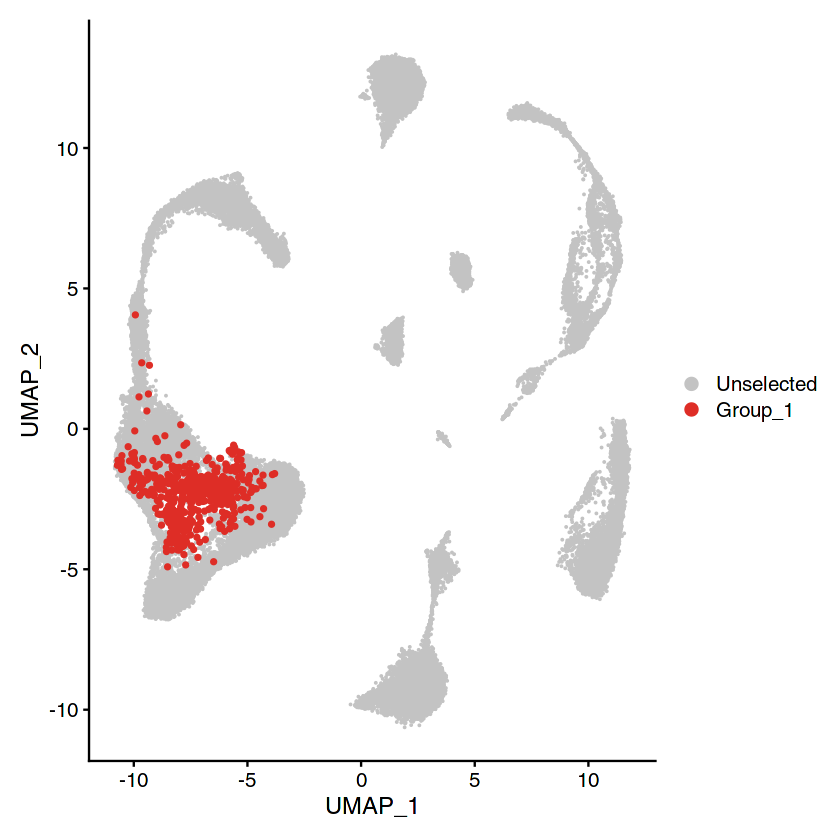

In [18]:
library(ggplot2)
library(scales)
DimPlot(testis, cells.highlight = Cells(testis) %>% subset(testis$ident == "spermatid"))

In [102]:
saveRDS(testis, "testis-spca.rds")